In [1]:
import sys
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

print(sys.executable)

c:\Users\Lenovo\Desktop\projects_GitHub\fitness-calories-eda\venv\Scripts\python.exe


In [2]:
exercise = pd.read_csv("../data/raw/exercise.csv")
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [3]:

exercise.shape


(15000, 8)

In [4]:
exercise.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
dtypes: float64(5), int64(2), str(1)
memory usage: 937.6 KB


In [5]:
exercise.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000


In [6]:
calories = pd.read_csv("../data/raw/calories.csv")
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [7]:
calories.shape

(15000, 2)

In [8]:
calories.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB


In [9]:
calories.describe()

,User_ID,Calories
count,1.500000e+04,15000.000000
mean,1.497736e+07,89.539533
std,2.872851e+06,62.456978
min,1.000116e+07,1.000000
25%,1.247419e+07,35.000000
50%,1.499728e+07,79.000000
75%,1.744928e+07,138.000000
max,1.999965e+07,314.000000


## Initial Data Overview

**Exercise dataset (15000 × 8):**
Columns — User_ID (id), Gender (cat), Age (years), Height (cm),
Weight (kg), Duration (min), Heart_Rate (bpm), Body_Temp (°C).

**Calories dataset (15000 × 2):**
Columns — User_ID (id), Calories (kcal).

**Ranges look reasonable?**
All columns fall within plausible physiological ranges:
- Age 20–79, Height 123–222 cm, Weight 36–132 kg
- Duration 1–30 min, Heart_Rate 67–128 bpm, Body_Temp 37.1–41.5 °C
- Calories 1–314 kcal

No negative, zero, or clearly impossible values at first glance.

In [10]:
def check_key(df: pd.DataFrame, name: str, key: str = "User_ID") -> None:
    print(f"{name}: rows={len(df)}, unique {key}={df[key].nunique()}, is_unique={df[key].is_unique}")

check_key(exercise, "exercise")
check_key(calories, "calories")

exercise: rows=15000, unique User_ID=15000, is_unique=True
calories: rows=15000, unique User_ID=15000, is_unique=True


In [11]:
exercise_ids = set(exercise['User_ID'])
calories_ids = set(calories['User_ID'])

only_in_exercise = exercise_ids - calories_ids
only_in_calories = calories_ids - exercise_ids

print("only in exercise:", len(only_in_exercise))
print("only in calories:", len(only_in_calories))
print("same ID sets:", exercise_ids == calories_ids)
print("Intersection size:", len(exercise_ids & calories_ids))

only in exercise: 0
only in calories: 0
same ID sets: True
Intersection size: 15000


## User_ID Validation

**Results:**
- exercise: 15000 rows, 15000 unique User_IDs → unique
- calories: 15000 rows, 15000 unique User_IDs → unique
- ID sets are identical: no ID exists in only one file.

**Implication for Merge:**
Since both keys are unique and the ID sets match exactly,
`inner` and `left` joins will produce the same number of rows (15000).
I will use `inner` for safety and clarity.

In [12]:
def audit_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate a data quality audit table for each column of the input DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to be audited.

    Returns
    -------
    pd.DataFrame
        A DataFrame indexed by column name with the following metrics:
        - dtype     : data type of the column
        - non_null  : number of non-missing values
        - missing   : number of missing values
        - missing_% : percentage of missing values (0–100), rounded to 2 decimals
        - n_unique  : number of unique values in the column
    """
    audit = pd.DataFrame({
        "dtype":     df.dtypes,
        "non_null":  df.notna().sum(),
        "missing":   df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "n_unique":  df.nunique(),
    })
    return audit

In [13]:
print("Shape:", exercise.shape)
print("duplicated rows:", exercise.duplicated().sum())
print()
audit_table(exercise)

Shape: (15000, 8)
duplicated rows: 0



,dtype,non_null,missing,missing_%,n_unique
User_ID,int64,15000,0,0.0,15000
Gender,str,15000,0,0.0,2
Age,int64,15000,0,0.0,60
Height,float64,15000,0,0.0,90
Weight,float64,15000,0,0.0,91
Duration,float64,15000,0,0.0,30
Heart_Rate,float64,15000,0,0.0,59
Body_Temp,float64,15000,0,0.0,45


In [14]:

print("Shape:", calories.shape)
print("duplicated rows:", calories.duplicated().sum())
print()
audit_table(calories)

Shape: (15000, 2)
duplicated rows: 0



,dtype,non_null,missing,missing_%,n_unique
User_ID,int64,15000,0,0.0,15000
Calories,float64,15000,0,0.0,277


## Data Audit Summary

**Missing values:** none in either dataset (0 across all columns).

**Duplicates:**
- exercise: 0 fully duplicated rows
- calories: 0 fully duplicated rows

**User_ID:** unique in both files (15000 = 15000). It is an identifier,
so it should NOT be used in numerical analysis (mean/median/correlation).

**Missing %:** all columns show 0.0% missing.

In [15]:
num_cols = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp"]
print("values <= 0 per column:")
print((exercise[num_cols] <= 0).sum())
print("Calories <= 0:", (calories["Calories"] <= 0).sum())

print(exercise["Gender"].value_counts())

print("duplicate User_ID (exercise):", exercise.duplicated(subset="User_ID").sum())
print("duplicate User_ID (calories):", calories.duplicated(subset="User_ID").sum())

values <= 0 per column:
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64
Calories <= 0: 0
Gender
female    7553
male      7447
Name: count, dtype: int64
duplicate User_ID (exercise): 0
duplicate User_ID (calories): 0


## Missing, Duplicate & Hidden Missing

**Real missing values:** none.

**Hidden missing check (values that behave like missing):**
- Duration <= 0: 0
- Heart_Rate <= 0: 0
- Body_Temp <= 0: 0
- Age <= 0: 0
- Height <= 0: 0
- Weight <= 0: 0
- Calories <= 0: 0

**Duplicates:**
- Fully duplicated rows: 0 in both files
- Duplicated User_ID: 0 in both files

**Final decision:**
No missing values and no duplicates were found.
No rows were dropped and no imputation was applied.
The data is clean and ready for outlier analysis.

In [16]:
df = exercise.merge(calories,on="User_ID",how="inner",validate="one_to_one")
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [17]:
print("exercise shape:", exercise.shape)
print("calories shape:", calories.shape)
print("merged shape:  ", df.shape)
print()
print("row count preserved?", len(df) == len(exercise))
print("calories has NaN?", df["Calories"].isna().sum())
print("id unique in merged?", df["User_ID"].is_unique)

exercise shape: (15000, 8)
calories shape: (15000, 2)
merged shape:   (15000, 9)

row count preserved? True
calories has NaN? 0
id unique in merged? True


In [18]:
test_merge = exercise.merge(calories,on="User_ID",how="outer",indicator=True)
print(test_merge['_merge'].value_counts())

_merge
both          15000
left_only         0
right_only        0
Name: count, dtype: int64


In [19]:
print("merged shape:", df.shape)
print("duplicated rows:", df.duplicated().sum())
print("duplicated User id:", df.duplicated(subset="User_ID").sum())
print()
audit_table(df)

merged shape: (15000, 9)
duplicated rows: 0
duplicated User id: 0



,dtype,non_null,missing,missing_%,n_unique
User_ID,int64,15000,0,0.0,15000
Gender,str,15000,0,0.0,2
Age,int64,15000,0,0.0,60
Height,float64,15000,0,0.0,90
Weight,float64,15000,0,0.0,91
Duration,float64,15000,0,0.0,30
Heart_Rate,float64,15000,0,0.0,59
Body_Temp,float64,15000,0,0.0,45
Calories,float64,15000,0,0.0,277


## Merge Decision

**Merge type:** `inner`

**Why inner?**
- Both files share the same User_ID set (verified in step 2).
- `inner` and `left` would produce identical results here.
- `inner` is chosen because it guarantees we only keep rows with both exercise and calorie data.

**Why `validate="one_to_one"`?**
- It raises an error if the key is duplicated on either side.
- A duplicated key in a merge causes a cartesian product:
  rows multiply (e.g. 1 duplicated ID × 2 matches = 2 rows instead of 1).
- With `one_to_one`, we catch this bug immediately instead of silently
  inflating the dataset.

**Result:**
- exercise: 15000 × 8
- calories: 15000 × 2
- merged:   15000 × 9  →  row count preserved

In [20]:
def iqr_bounds(s: pd.Series, k: float = 1.5) -> tuple[float, float]:
    """
    Compute IQR-based lower and upper bounds for outlier detection.

    Parameters
    ----------
    s : pd.Series
        Numeric series to analyze.
    k : float, default 1.5
        IQR multiplier. 1.5 = standard; 3.0 = extreme outliers only.

    Returns
    -------
    tuple[float, float]
        (lower_bound, upper_bound)
    """
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

In [21]:
numeric_cols = ["Age","Height","Weight","Duration","Heart_Rate","Body_Temp","Calories"]
rows = []
for col in numeric_cols:
    s = df[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    lower, upper = iqr_bounds(s)
    n_out = ((s < lower) | (s > upper)).sum()
    rows.append({
        "column":     col,
        "Q1":         round(q1, 2),
        "Q3":         round(q3, 2),
        "lower":      round(lower, 2),
        "upper":      round(upper, 2),
        "n_outliers": n_out,
        "outlier_%":  round(n_out / len(s) * 100, 2),
    })

outlier_table = pd.DataFrame(rows)
outlier_table

,column,Q1,Q3,lower,upper,n_outliers,outlier_%
0,Age,28.0,56.0,-14.0,98.0,0,0.00
1,Height,164.0,185.0,132.5,216.5,14,0.09
2,Weight,63.0,87.0,27.0,123.0,6,0.04
3,Duration,8.0,23.0,-14.5,45.5,0,0.00
4,Heart_Rate,88.0,103.0,65.5,125.5,1,0.01
5,Body_Temp,39.6,40.6,38.1,42.1,369,2.46
6,Calories,35.0,138.0,-119.5,292.5,4,0.03


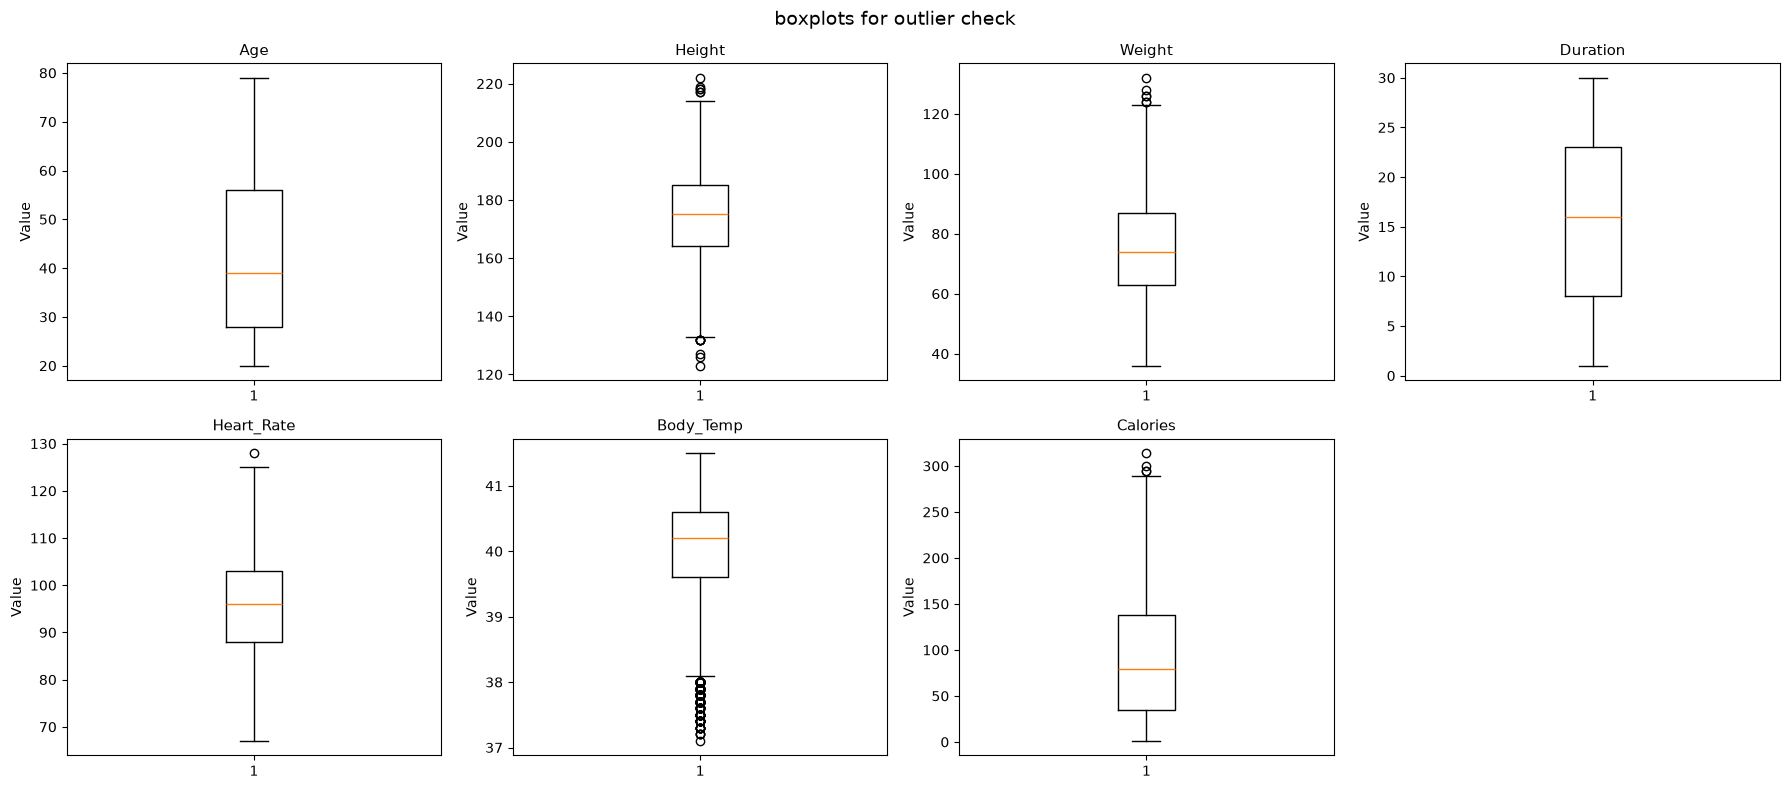

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Value")

axes[-1].axis("off")

plt.suptitle("boxplots for outlier check", fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
for col in numeric_cols:
    lower, upper = iqr_bounds(df[col])
    outliers = df[col][(df[col] < lower) | (df[col] > upper)]
    if len(outliers) > 0:
        print(f"\n {col}")
        print(f"lower: {lower:.2f}, upper: {upper:.2f}")
        print(f"min outlier: {outliers.min():.2f}, max outlier: {outliers.max():.2f}")
        print(f"count: {len(outliers)}")


 Height
lower: 132.50, upper: 216.50
min outlier: 123.00, max outlier: 222.00
count: 14

 Weight
lower: 27.00, upper: 123.00
min outlier: 124.00, max outlier: 132.00
count: 6

 Heart_Rate
lower: 65.50, upper: 125.50
min outlier: 128.00, max outlier: 128.00
count: 1

 Body_Temp
lower: 38.10, upper: 42.10
min outlier: 37.10, max outlier: 38.00
count: 369

 Calories
lower: -119.50, upper: 292.50
min outlier: 295.00, max outlier: 314.00
count: 4


In [24]:
z_rows = []
for col in numeric_cols:
    s = df[col]
    z = np.abs(stats.zscore(s))
    n_out_z = (z > 3).sum()
    z_rows.append({"column": col, "n_outliers_zscore": n_out_z})

z_table = pd.DataFrame(z_rows)
comparison = outlier_table[["column", "n_outliers", "outlier_%"]].merge(z_table, on="column")
comparison

,column,n_outliers,outlier_%,n_outliers_zscore
0,Age,0,0.00,0
1,Height,14,0.09,7
2,Weight,6,0.04,13
3,Duration,0,0.00,0
4,Heart_Rate,1,0.01,3
5,Body_Temp,369,2.46,76
6,Calories,4,0.03,7


## Outlier Analysis

**IQR summary:**

| Column | n_outliers | outlier_% |
|---|---:|---:|
| Age | 0 | 0.00% |
| Height | 14 | 0.09% |
| Weight | 6 | 0.04% |
| Duration | 0 | 0.00% |
| Heart_Rate | 1 | 0.01% |
| Body_Temp | 369 | 2.46% |
| Calories | 4 | 0.03% |

**Decision: keep all outliers.**

- Age & Duration: 0 outliers → no action.
- Height (14), Weight (6), Heart_Rate (1), Calories (4): all < 0.1%.
  Values are physiologically plausible (e.g. Height 222 cm = tall athlete);
  removing them would bias the analysis.
- Body_Temp (369 = 2.46%): flagged by IQR **not because they are errors**,
  but because the distribution is left-skewed (most values are high).
  Values like 37.5 °C are normal at rest → keep.

**IQR vs Z-score:**
Z-score flagged fewer for Height (7 vs 14) and Body_Temp (76 vs 369),
but more for Weight (13 vs 6). IQR was chosen because it does not assume
normality, while our data is skewed.

**Final action:** No rows removed, no capping applied.

In [25]:
print("gender value counts:")
print(df["Gender"].value_counts())
print()
print("unique raw values:", df["Gender"].unique())
print("dtype before:", df["Gender"].dtype)

gender value counts:
Gender
female    7553
male      7447
Name: count, dtype: int64

unique raw values: <StringArray>
['male', 'female']
Length: 2, dtype: str
dtype before: str


In [26]:
mem_before = df.memory_usage(deep=True).sum()

df["Gender"] = df["Gender"].str.strip().str.lower().astype("category")

mem_after = df.memory_usage(deep=True).sum()

print(f"memory before: {mem_before:,} bytes")
print(f"memory after:  {mem_after:,} bytes")
print(f"Saved:         {mem_before - mem_after:,} bytes ({(mem_before - mem_after) / mem_before * 100:.2f}%)")
print()
print("dtype after:", df["Gender"].dtype)
print("categories:", df["Gender"].cat.categories.tolist())

memory before: 1,890,238 bytes
memory after:  975,256 bytes
Saved:         914,982 bytes (48.41%)

dtype after: category
categories: ['female', 'male']


In [27]:
print(df.dtypes)
print()
print("=== Memory per column ===")
print(df.memory_usage(deep=True))

User_ID          int64
Gender        category
Age              int64
Height         float64
Weight         float64
Duration       float64
Heart_Rate     float64
Body_Temp      float64
Calories       float64
dtype: object

=== Memory per column ===
Index            132
User_ID       120000
Gender         15124
Age           120000
Height        120000
Weight        120000
Duration      120000
Heart_Rate    120000
Body_Temp     120000
Calories      120000
dtype: int64


## Data Type Correction

- `Gender` → `category`. Only 2 unique values (female/male), so this saves memory and marks it as nominal.
- Memory: 1.89 MB → 0.98 MB (saved 48.4%).
- `User_ID` kept as `int64` — it's an identifier, not a numeric feature.
- All float columns kept as `float64` (continuous values).

**Why not category everywhere?**
Not suitable for high-cardinality columns or free-text fields — 
it would use more memory, not less.

In [28]:
print("duration min:", df["Duration"].min())
print("duration == 0:", (df["Duration"] == 0).sum())
print()
print("height range:", df["Height"].min(), "to", df["Height"].max())
print("weight range:", df["Weight"].min(), "to", df["Weight"].max())

duration min: 1.0
duration == 0: 0

height range: 123.0 to 222.0
weight range: 36.0 to 132.0


In [29]:
df["BMI"] = df["Weight"] / (df["Height"] / 100) ** 2
df["BMI"].describe()

count    15000.000000
mean        24.344900
std          1.558784
min         19.227688
25%         23.243408
50%         24.376731
75%         25.492722
max         29.069767
Name: BMI, dtype: float64

In [30]:
df["Calories_per_Minute"] = df["Calories"] / df["Duration"]
df["Calories_per_Minute"].describe()

count    15000.000000
mean         5.201063
std          1.414868
min          0.500000
25%          4.250000
50%          5.200000
75%          6.166667
max         11.214286
Name: Calories_per_Minute, dtype: float64

In [31]:
bins = [20, 30, 40, 50, 60, 80]
labels = ["20-29", "30-39", "40-49", "50-59", "60+"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)
df["Age_Group"].value_counts().sort_index()

Age_Group
20-29    4387
30-39    3115
40-49    2394
50-59    2011
60+      3093
Name: count, dtype: int64

In [32]:
bmi_bins = [0, 18.5, 25, 30, np.inf]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese"]

df["BMI_Group"] = pd.cut( df["BMI"], bins=bmi_bins, labels=bmi_labels, right=False)
df["BMI_Group"].value_counts().sort_index()

BMI_Group
Underweight       0
Normal         9792
Overweight     5208
Obese             0
Name: count, dtype: int64

In [33]:
print("BMI < 10 (impossible):", (df["BMI"] < 10).sum())
print("BMI > 60 (impossible):", (df["BMI"] > 60).sum())
print()
print("BMI min:", df["BMI"].min().round(2))
print("BMI max:", df["BMI"].max().round(2))

BMI < 10 (impossible): 0
BMI > 60 (impossible): 0

BMI min: 19.23
BMI max: 29.07


In [34]:
new_cols = ["BMI", "Calories_per_Minute", "Age_Group", "BMI_Group"]
print(df[new_cols].isna().sum())

BMI                    0
Calories_per_Minute    0
Age_Group              0
BMI_Group              0
dtype: int64


## Feature Engineering

Four new columns were created using vectorized operations (no loops, no apply).

| Feature | Formula | Actual range | Why |
|---|---|---|---|
| `BMI` | `Weight / (Height/100)**2` | 19.23 – 29.07 | Standard body-mass index; needed for BMI-group analysis. |
| `Calories_per_Minute` | `Calories / Duration` | 0.50 – 11.21 | Normalizes calorie burn by time; useful for comparing workout intensity. |
| `Age_Group` | `pd.cut(Age, bins=[20,30,40,50,60,80])` | 5 groups | Reduces noise from single ages; needed for pivot tables. |
| `BMI_Group` | `pd.cut(BMI, bins=[0,18.5,25,30,inf])` | 4 groups | WHO standard categories; enables categorical comparison. |

**All operations are vectorized** using NumPy/Pandas — no Python loops.

**Sanity checks:**
- No NaN in any new column (checked).
- BMI range 19.23–29.07 — narrow, no impossible values.
- Duration > 0, so `Calories_per_Minute` is safe.

**Note on BMI_Group:** Underweight and Obese are both empty
(0 rows) — the dataset only contains Normal and Overweight.
The comparison in analysis will be between these two groups only.

In [35]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)
print("saved to ../data/processed/cleaned_data.csv")

saved to ../data/processed/cleaned_data.csv


In [36]:
df_check = pd.read_csv("../data/processed/cleaned_data.csv")
print("Shape:", df_check.shape)
print()
print("dtypes:")
print(df_check.dtypes)
print()
print("first 3 rows:")
df_check.head(3)

Shape: (15000, 13)

dtypes:
User_ID                  int64
Gender                     str
Age                      int64
Height                 float64
Weight                 float64
Duration               float64
Heart_Rate             float64
Body_Temp              float64
Calories               float64
BMI                    float64
Calories_per_Minute    float64
Age_Group                  str
BMI_Group                  str
dtype: object

first 3 rows:


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Calories_per_Minute,Age_Group,BMI_Group
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0,26.038781,7.965517,60+,Overweight
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0,21.773842,4.714286,20-29,Normal
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0,24.655910,5.200000,60+,Normal


## Saving the Cleaned Dataset

Saved to `data/processed/cleaned_data.csv` with `index=False`.

**Verification:**
- Shape preserved: (15000, 13).
- CSV does not preserve `category` dtype — `Gender`, `Age_Group`, and
  `BMI_Group` will be read back as strings.
- In `02_analysis.ipynb`, these columns must be re-cast to `category` after loading.

## Cleaning Summary

| Stage | Detail |
|---|---|
| Input rows (exercise) | 15000 |
| Input rows (calories) | 15000 |
| Output rows | 15000 |
| Rows removed | 0 |
| Input columns (merged) | 9 |
| Output columns | 13 |
| Columns added | `BMI`, `Calories_per_Minute`, `Age_Group`, `BMI_Group` |
| Missing values handled | None (0 found) |
| Duplicates handled | None (0 found) |
| Outliers | Detected, but **kept** (all physiologically plausible) |
| Data types corrected | `Gender` → `category` (saved 48.4% memory) |
| Merge type | `inner` with `validate="one_to_one"` |
| Output file | `data/processed/cleaned_data.csv` |